In [1]:
import sys
sys.path.append("../scripts")

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Load processed data
combined = pd.read_csv("../data/processed/combined_labor_data.csv", parse_dates=["date"])
oews = pd.read_csv("../data/processed/oews_processed.csv")

print("Combined shape:", combined.shape)
print("OEWS shape:", oews.shape)
print(combined.dtypes)

Combined shape: (216, 10)
OEWS shape: (809, 6)
series_id                             str
industry                              str
unemployment_rate_bls             float64
date                       datetime64[us]
JOLTS_openings                    float64
avg_hourly_earnings               float64
cpi                               float64
unemployment_yoy_change           float64
unemployment_3m_avg               float64
wage_vs_inflation                 float64
dtype: object


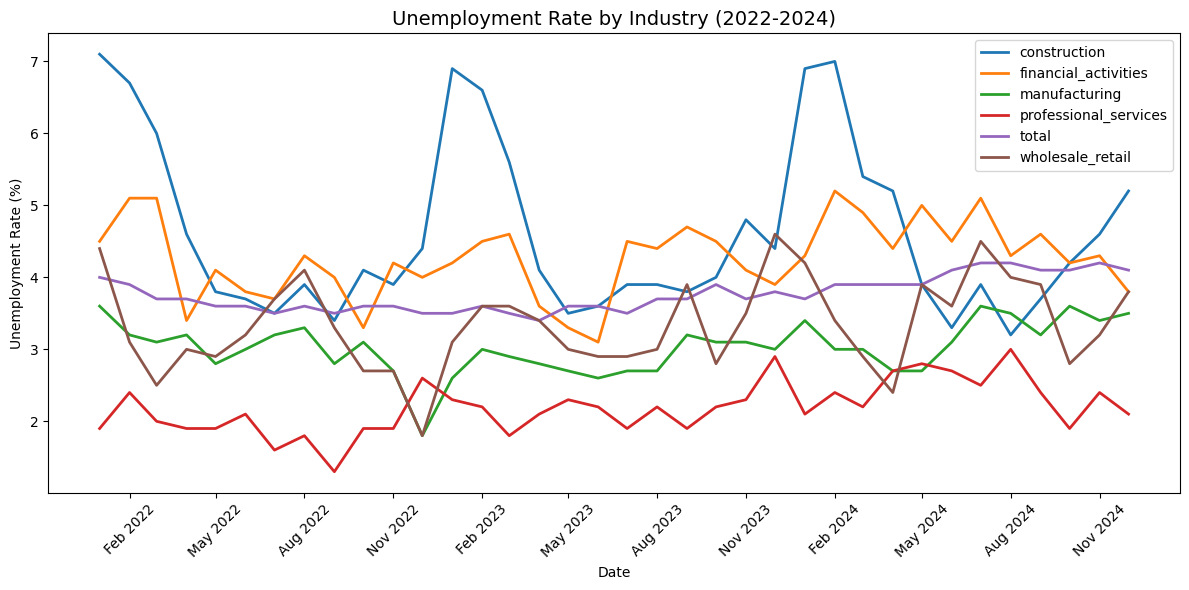

In [2]:
fig, ax = plt.subplots(figsize=(12, 6))

industries = combined["industry"].unique()

for industry in industries:
    data = combined[combined["industry"] == industry].sort_values("date")
    ax.plot(data["date"], data["unemployment_rate_bls"], label=industry, linewidth=2)

ax.set_title("Unemployment Rate by Industry (2022-2024)", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Unemployment Rate (%)")
ax.legend(loc="upper right")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

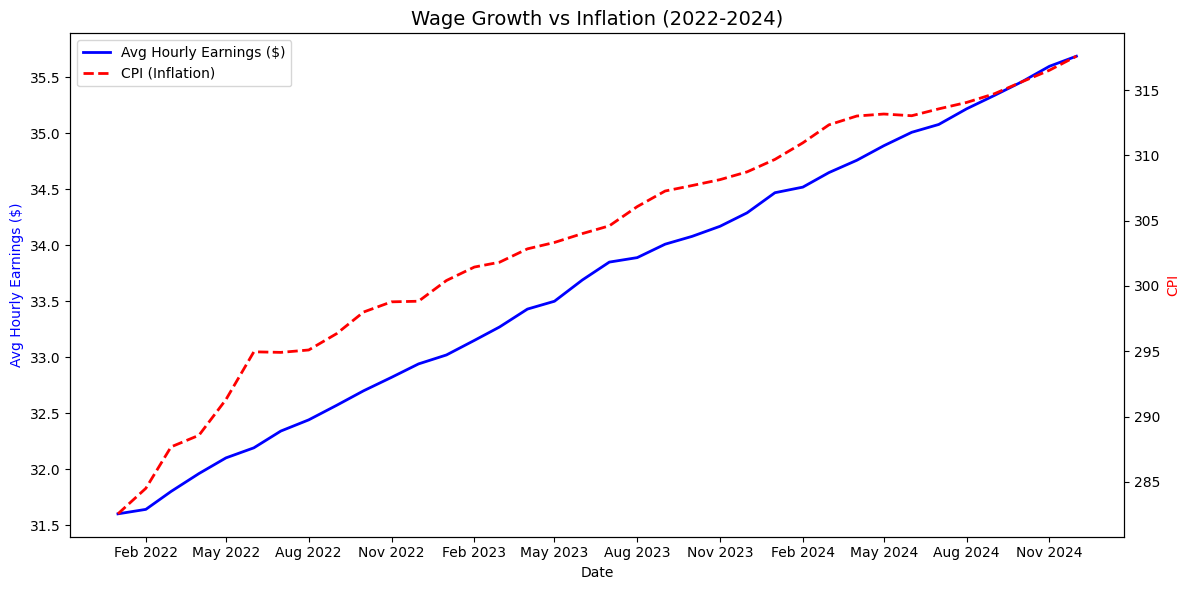

In [3]:
# Get one row per date since these are national figures
macro = combined.drop_duplicates(subset=["date"]).sort_values("date")

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(macro["date"], macro["avg_hourly_earnings"], 
        color="blue", linewidth=2, label="Avg Hourly Earnings ($)")
ax1.set_xlabel("Date")
ax1.set_ylabel("Avg Hourly Earnings ($)", color="blue")

ax2 = ax1.twinx()
ax2.plot(macro["date"], macro["cpi"], 
        color="red", linewidth=2, linestyle="--", label="CPI (Inflation)")
ax2.set_ylabel("CPI", color="red")

ax1.set_title("Wage Growth vs Inflation (2022-2024)", fontsize=14)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()

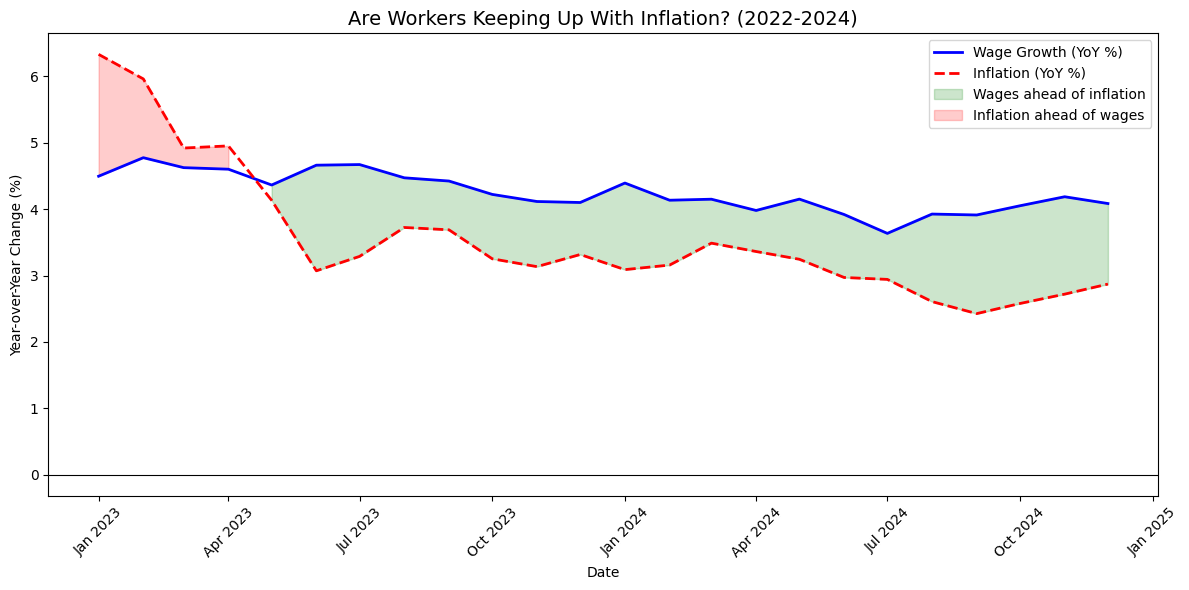

In [4]:
# Calculate year over year percentage change for both

macro = macro.copy()
macro["wage_growth_pct"] = macro["avg_hourly_earnings"].pct_change(periods=12) * 100
macro["inflation_pct"] = macro["cpi"].pct_change(periods=12) * 100

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(macro["date"], macro["wage_growth_pct"], 
        color="blue", linewidth=2, label="Wage Growth (YoY %)")
ax.plot(macro["date"], macro["inflation_pct"], 
        color="red", linewidth=2, linestyle="--", label="Inflation (YoY %)")

ax.axhline(y=0, color="black", linewidth=0.8, linestyle="-")
ax.fill_between(macro["date"], macro["wage_growth_pct"], macro["inflation_pct"],
                where=macro["wage_growth_pct"] >= macro["inflation_pct"],
                alpha=0.2, color="green", label="Wages ahead of inflation")
ax.fill_between(macro["date"], macro["wage_growth_pct"], macro["inflation_pct"],
                where=macro["wage_growth_pct"] < macro["inflation_pct"],
                alpha=0.2, color="red", label="Inflation ahead of wages")

ax.set_title("Are Workers Keeping Up With Inflation? (2022-2024)", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Year-over-Year Change (%)")
ax.legend(loc="upper right")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

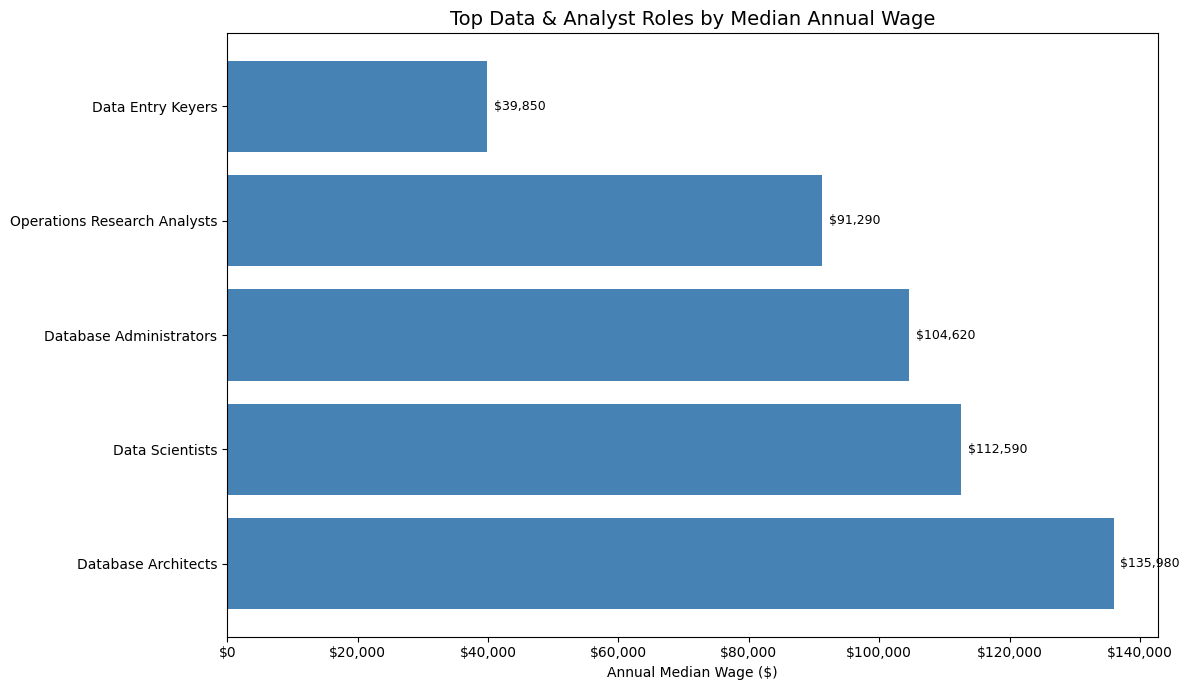

In [5]:
data_roles = oews[
    (oews["occ_title"].str.contains("Data|Business Analyst|Operations Research", 
                                    case=False, na=False))
].sort_values("a_median", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(data_roles["occ_title"], data_roles["a_median"], color="steelblue")
ax.set_xlabel("Annual Median Wage ($)")
ax.set_title("Top Data & Analyst Roles by Median Annual Wage", fontsize=14)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x:,.0f}"))

for bar, value in zip(bars, data_roles["a_median"]):
    ax.text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2,
            f"${value:,.0f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

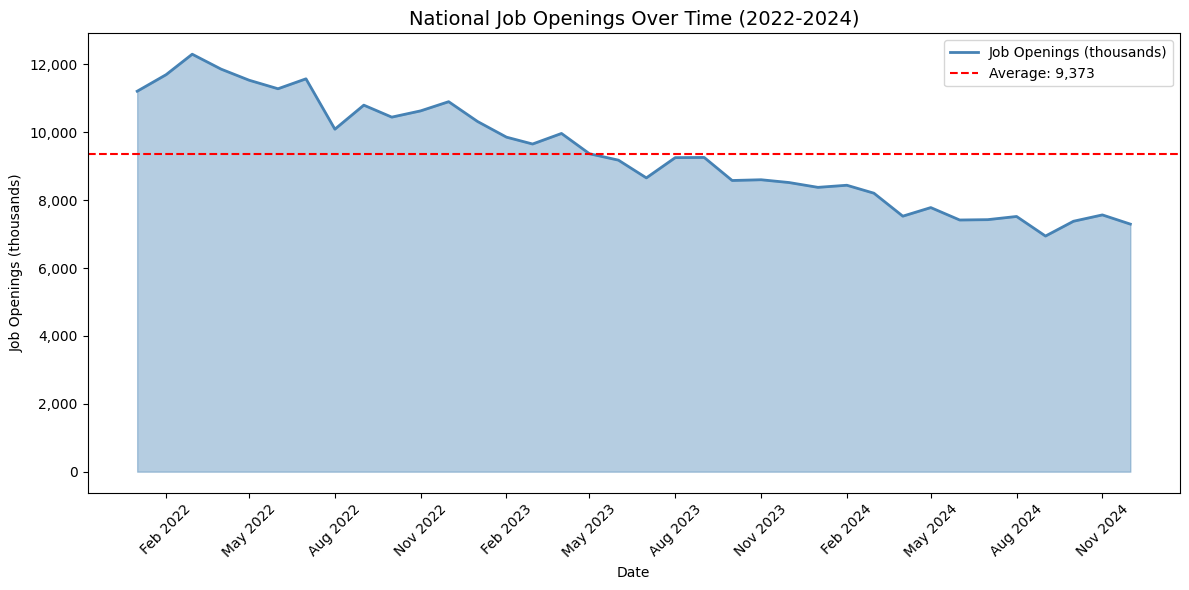

In [6]:
# Get one row per date since JOLTS is a national figure

# drop_duplicates ensures we don't count the same date 6 times (once per industry)
macro = combined.drop_duplicates(subset=["date"]).sort_values("date")

fig, ax = plt.subplots(figsize=(12, 6))

# Plot JOLTS openings as a filled area chart
ax.fill_between(macro["date"], macro["JOLTS_openings"], 
                alpha=0.4, color="steelblue")
ax.plot(macro["date"], macro["JOLTS_openings"], 
        color="steelblue", linewidth=2, label="Job Openings (thousands)")

# Add a horizontal line at the average to show context
avg_openings = macro["JOLTS_openings"].mean()
ax.axhline(y=avg_openings, color="red", linewidth=1.5, 
           linestyle="--", label=f"Average: {avg_openings:,.0f}")

# Format y axis with commas for readability
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{x:,.0f}"))

ax.set_title("National Job Openings Over Time (2022-2024)", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Job Openings (thousands)")
ax.legend(loc="upper right")

# Format x axis to show month and year every 3 months
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)

plt.tight_layout()

## Key findings

**Chart 1 — Unemployment by industry:**
Construction shows strong seasonal spikes every January due to weather-related slowdowns, 
peaking above 7% in early 2022. Professional services consistently maintained the lowest 
unemployment rates, reflecting the stability of knowledge-based work.

**Chart 2 & 3 — Wages vs inflation:**
Workers experienced real purchasing power losses in early 2023 when inflation peaked above 
wage growth. By mid-2023 the trend reversed as Fed rate hikes cooled inflation while wage 
growth remained steady — workers began gaining real purchasing power again.

**Chart 4 — Job openings:**
National job openings declined significantly from their 2022 peak, falling below the 
period average by September 2023 and remaining there. This reflects the broader cooling 
of the post-pandemic hiring boom.

**Chart 5 — Data role wages (OEWS):**
Data architects lead analyst-adjacent roles at $135,980 median annual wage. 
Business analysts and operations research analysts fall in the $85,000-$100,000 range, 
representing strong targets for mid-career transitions into data work.